In [22]:
# Cell 1: Setup
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# 添加项目根目录
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.environment import compute_nash_and_monopoly_static, get_demand_and_profit_static
from src.strategies import (
    ACT_UNDERCUT, ACT_MATCH, ACT_ABOVE, 
    ACT_UNDER_RESET, ACT_MATCH_RESET,
    ID_TO_NAME, get_strategy_function
)

print("Ready to simulate physics without building lookup tables.")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Ready to simulate physics without building lookup tables.


In [23]:
# Cell 2: 定义微观模拟函数 (Micro-Simulation)

def simulate_inner_dynamics(
    n_sellers,
    active_strategies,
    fixed_actions,
    start_prices=None,
    K=50,
    mu=0.25,
    a_val=2.0,
    c_val=1.0,
    a0=0.0,
    xi=0.1,
    num_grids=10,
):
    """
    模拟在固定的 Action 组合下 K 期内的价格演变，不依赖 lookup table。
    Args:
        n_sellers: 玩家数量
        active_strategies: 允许使用的策略列表 (Global IDs)
        fixed_actions: 每个玩家选择的策略 (Global ID)，例 [ACT_UNDER_RESET, ACT_MATCH]
        start_prices: 初始价格索引列表 (0~num_grids-1). None 则随机。
        K: 模拟步数
        mu,a_val,c_val,a0,xi,num_grids: 经济与网格参数，与 Config 默认保持一致。
    """
    # 1. 计算基准价格并构造价格网格
    p_nash, p_mon = compute_nash_and_monopoly_static(
        num_sellers=n_sellers,
        a_val=a_val,
        mu=mu,
        a0=a0,
        c_val=c_val,
    )
    low = p_nash - xi * (p_mon - p_nash)
    high = p_mon + xi * (p_mon - p_nash)
    price_grid = np.linspace(low, high, num_grids)

    # 2. 初始状态（价格索引）
    if start_prices is None:
        current_indices = [np.random.randint(0, num_grids) for _ in range(n_sellers)]
    else:
        current_indices = start_prices

    # 3. 策略函数（按 Global ID）
    funcs = [get_strategy_function(gid) for gid in fixed_actions]

    # 4. 跑 K 步循环
    history = []
    for k in range(K):
        step_data = {"k": k}

        prices_val = [price_grid[idx] for idx in current_indices]
        for i, p in enumerate(prices_val):
            step_data[f"p_{i}"] = p

        profits = get_demand_and_profit_static(prices_val, a_val, mu, a0, c_val)
        for i, pi in enumerate(profits):
            step_data[f"profit_{i}"] = pi

        history.append(step_data)

        # 下一步索引
        next_indices = []
        for i in range(n_sellers):
            my_idx = current_indices[i]
            others_idx = current_indices[:i] + current_indices[i+1:]
            others_min = min(others_idx)
            next_p = funcs[i](my_idx, others_min, num_grids)
            next_indices.append(next_p)

        current_indices = next_indices

    return pd.DataFrame(history), price_grid


In [24]:
def plot_micro_dynamics(df, title, strategy_names=None):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    price_cols = [c for c in df.columns if c.startswith("p_")]
    prof_cols = [c for c in df.columns if c.startswith("profit_")]
    n = max(len(price_cols), len(prof_cols))
    shift = 0.1
    offsets = (np.arange(n) - (n - 1) / 2) * shift

    # Price trajectories (step with offsets)
    for idx, col in enumerate(price_cols):
        x = df["k"] + offsets[idx]
        label_core = f"Seller {col.split('_')[1]}"
        if strategy_names:
            label_core += f" ({strategy_names[idx]})"
        axes[0].step(
            x,
            df[col],
            where="mid",
            marker="o",
            markersize=3,
            label=label_core,
        )

    axes[0].set_title(f"Price Trajectory - {title}")
    axes[0].set_xlabel("Inner Step (k)")
    axes[0].set_ylabel("Price")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Profit trajectories (step with offsets)
    for idx, col in enumerate(prof_cols):
        x = df["k"] + offsets[idx]
        label_core = f"Seller {col.split('_')[1]}"
        if strategy_names:
            label_core += f" ({strategy_names[idx]})"
        axes[1].step(
            x,
            df[col],
            where="mid",
            linestyle="--",
            marker="o",
            markersize=3,
            label=label_core,
        )

    axes[1].set_title("Profit Trajectory")
    axes[1].set_xlabel("Inner Step (k)")
    axes[1].set_ylabel("Profit")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [25]:
def plot_micro_price_dynamics(df, title, strategy_names=None):
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    price_cols = [c for c in df.columns if c.startswith("p_")]
    n = len(price_cols)
    shift = 0.1
    offsets = (np.arange(n) - (n - 1) / 2) * shift

    for idx, col in enumerate(price_cols):
        x = df["k"] + offsets[idx]
        label_core = f"Seller {col.split('_')[1]}"
        if strategy_names:
            label_core += f" ({strategy_names[idx]})"
        ax.step(
            x,
            df[col],
            where="mid",
            marker="o",
            markersize=3,
            label=label_core,
        )

    ax.set_title(f"Price Trajectory - {title}")
    ax.set_xlabel("Inner Step (k)")
    ax.set_ylabel("Price")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


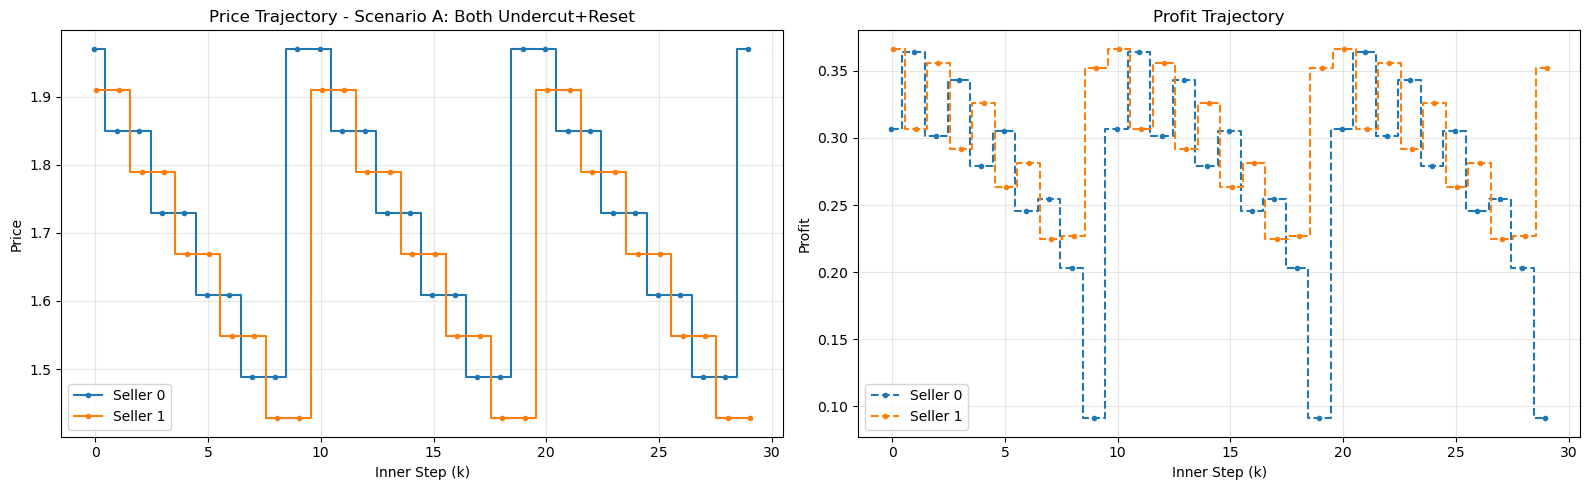

In [26]:
# Cell 4: 实验场景 A - 经典 Edgeworth Cycle 机制
# 设定: N=2, 两个人都用 "Undercut with Reset"
# 预期: 价格轮流下降，到底部后一人重置，另一人跟随重置

n = 2
strategies = [ACT_UNDER_RESET, ACT_MATCH_RESET, ACT_ABOVE]
actions = [ACT_UNDER_RESET, ACT_UNDER_RESET] # 两人都 Undercut+Reset

# 初始价格: 一个高一个低
start_p = [9, 8] # Grid Index (最高价, 次高价)

df_micro, grid = simulate_inner_dynamics(
    n_sellers=n, 
    active_strategies=strategies, 
    fixed_actions=actions, 
    start_prices=start_p, 
    K=30,  # 只需要看前30步
    mu=0.25
)

plot_micro_dynamics(df_micro, "Scenario A: Both Undercut+Reset")

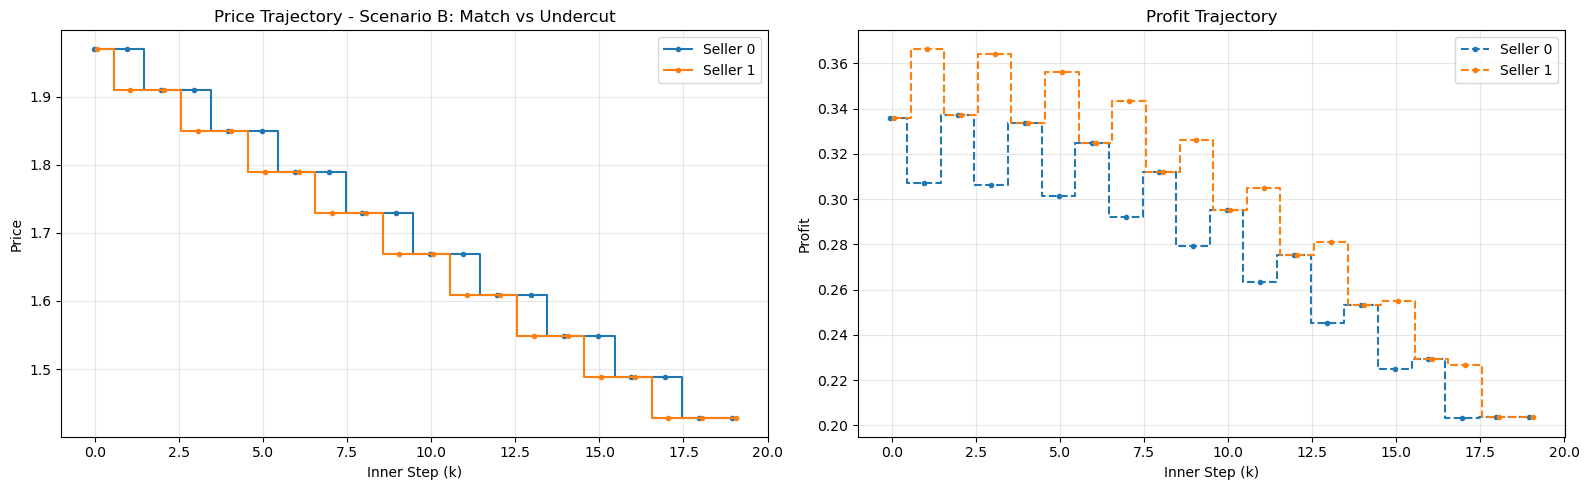

In [27]:
# Cell 5: 实验场景 B - 不对称策略
# 设定: N=2, Seller 0 用 "Match", Seller 1 用 "Undercut"
# 预期: Seller 1 拉低价格，Seller 0 跟随，直到降无可降 (Price War to Nash)

actions_b = [ACT_MATCH, ACT_UNDERCUT]

df_micro_b, _ = simulate_inner_dynamics(
    n_sellers=2, 
    active_strategies=[ACT_UNDERCUT, ACT_MATCH], 
    fixed_actions=actions_b, 
    start_prices=[9, 9], 
    K=20,
    mu=0.25
)

plot_micro_dynamics(df_micro_b, "Scenario B: Match vs Undercut")

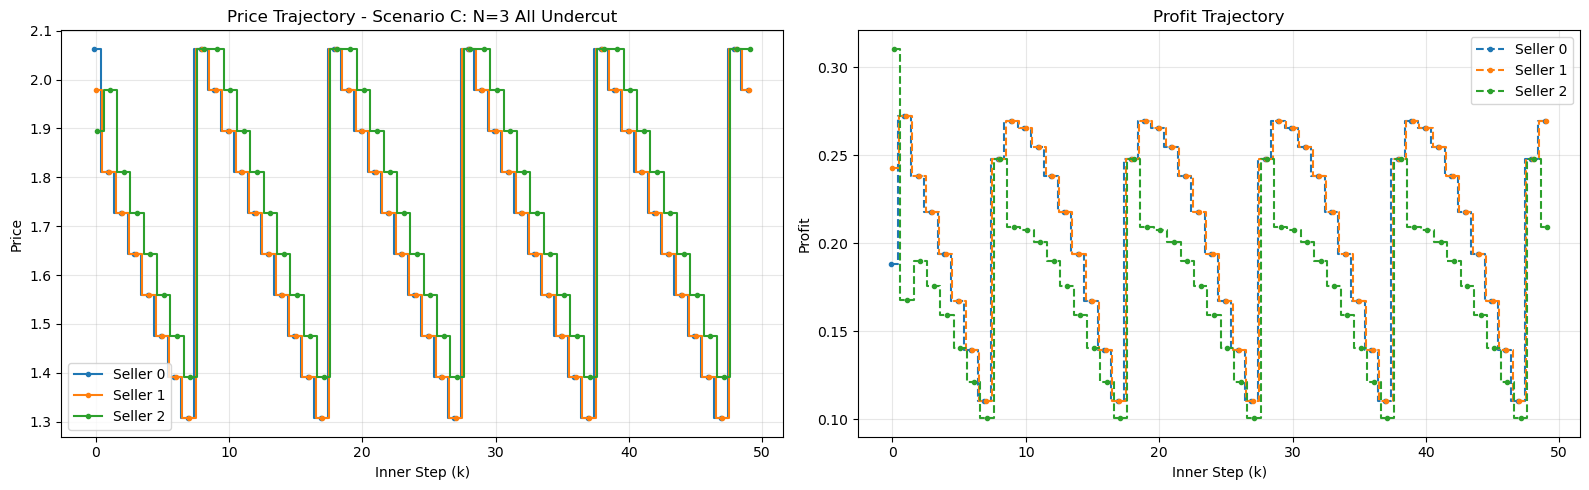

In [39]:
# Cell 6: 实验场景 C - N=3 的混乱
# 设定: N=3, 全部 Undercut+Reset

actions_c = [ACT_UNDER_RESET, ACT_UNDER_RESET, ACT_MATCH_RESET]

df_micro_c, _ = simulate_inner_dynamics(
    n_sellers=3, 
    active_strategies=strategies, 
    fixed_actions=actions_c, 
    start_prices=[9, 8, 7], 
    K=50,
    mu=0.25
)

plot_micro_dynamics(df_micro_c, "Scenario C: N=3 All Undercut")

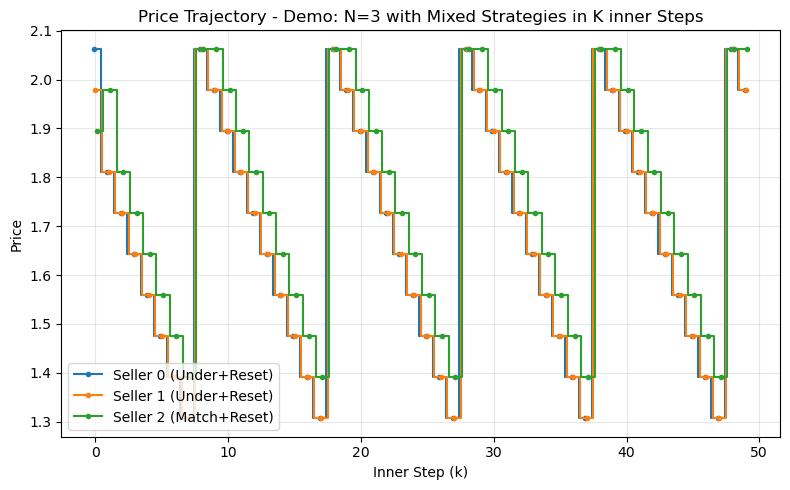

In [41]:
plot_micro_price_dynamics(df_micro_c, "Demo: N=3 with Mixed Strategies in K inner Steps",
                          strategy_names=[ID_TO_NAME[aid] for aid in actions_c])

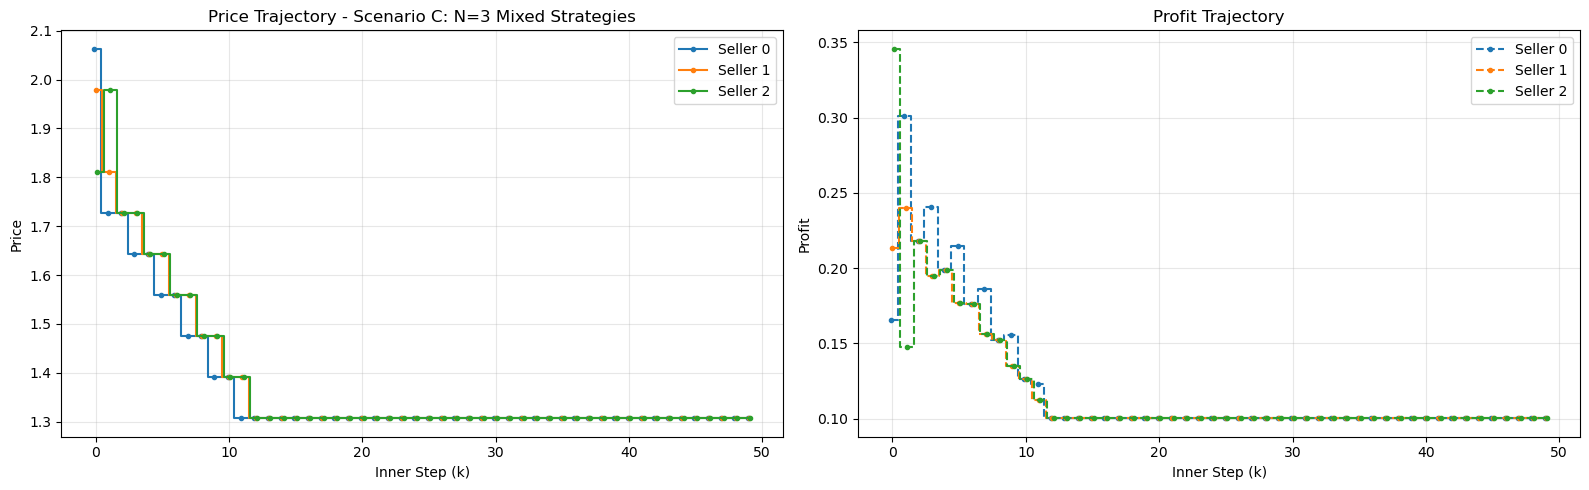

In [34]:
# Cell 7: 实验场景 C - N=3 的混乱
# 设定: N=4,  Undercut + Match + Above

actions_c = [ACT_UNDERCUT, ACT_MATCH, ACT_MATCH, ACT_ABOVE]

df_micro_c, _ = simulate_inner_dynamics(
    n_sellers=3, 
    active_strategies=strategies, 
    fixed_actions=actions_c, 
    start_prices=[9, 8, 6], 
    K=50,
    mu=0.25
)

plot_micro_dynamics(df_micro_c, "Scenario C: N=3 Mixed Strategies")

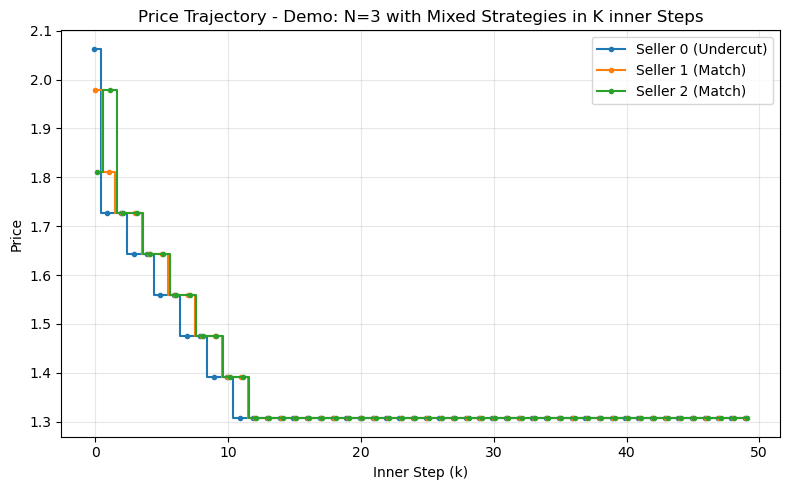

In [35]:
plot_micro_price_dynamics(df_micro_c, "Demo: N=3 with Mixed Strategies in K inner Steps",
                          strategy_names=[ID_TO_NAME[aid] for aid in actions_c])

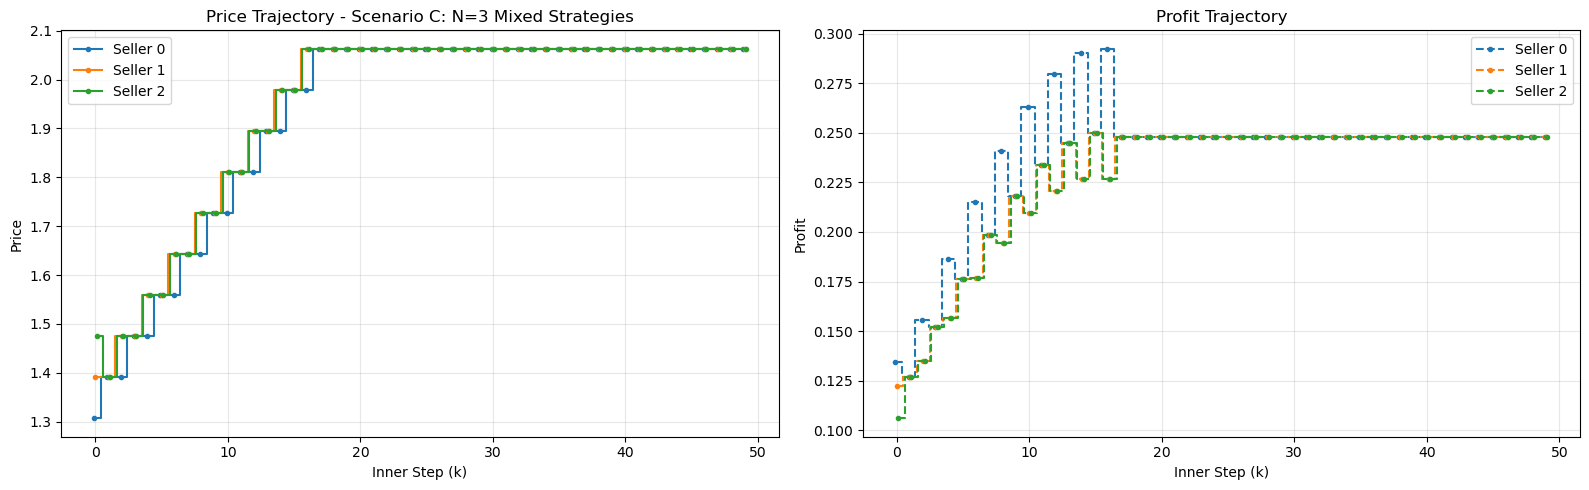

In [36]:
# Cell 8: 实验场景 C - N=3 Mixed
# 设定: N=3,  Match + Above

actions_c = [ACT_MATCH, ACT_ABOVE, ACT_ABOVE]

df_micro_c, _ = simulate_inner_dynamics(
    n_sellers=3, 
    active_strategies=strategies, 
    fixed_actions=actions_c, 
    start_prices=[0, 1, 2], 
    K=50,
    mu=0.25
)

plot_micro_dynamics(df_micro_c, "Scenario C: N=3 Mixed Strategies")

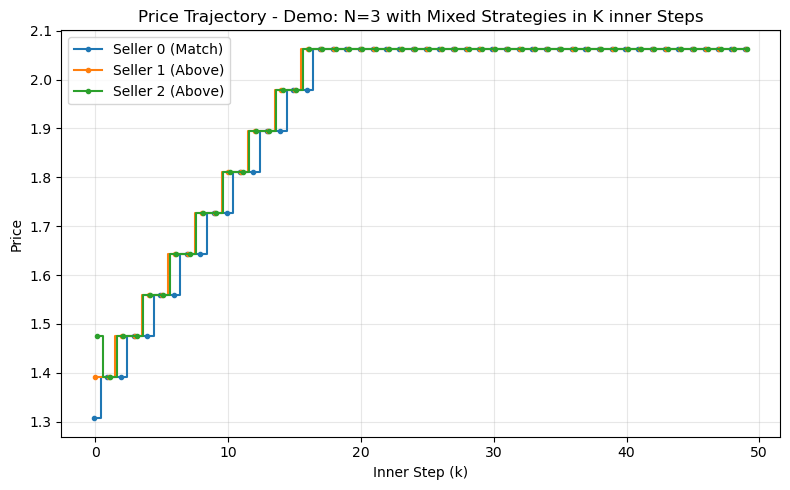

In [37]:
plot_micro_price_dynamics(df_micro_c, "Demo: N=3 with Mixed Strategies in K inner Steps",
                          strategy_names=[ID_TO_NAME[aid] for aid in actions_c])